<a href="https://colab.research.google.com/github/DVSkalyan-07/bar-inventory-forecasting/blob/main/notebooks/inventory_forecasting_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate synthetic date range (180 days)
dates = pd.date_range(start='2026-01-01', periods=180, freq='D')
bars = ['Rooftop_Bar', 'Lobby_Lounge', 'Pool_Bar']
brands = ['Brand_A_Whisky', 'Brand_B_Vodka', 'Brand_C_Gin', 'Brand_D_Rum']

records = []

for bar in bars:
    for brand in brands:
        opening = 5000.0  # Initial volume in ml
        for date in dates:
            # Weekend consumption multiplier
            is_weekend = date.dayofweek in [4, 5]
            mean_demand = 800.0 if is_weekend else 300.0
            consumed = round(max(0, np.random.normal(mean_demand, 100)), 2)

            # Restock logic if balance drops low
            purchase = 3000.0 if opening - consumed < 1000 else 0.0
            closing = opening + purchase - consumed

            # Format timestamp
            timestamp = date + pd.Timedelta(hours=np.random.randint(12, 23))

            records.append({
                'Date Time Served': timestamp,
                'Bar Name': bar,
                'Brand Name': brand,
                'Opening Balance': opening,
                'Purchase': purchase,
                'Consumed': consumed,
                'Closing Balance': closing
            })

            # Set opening for next iteration
            opening = max(0, closing)

# Create DataFrame and save as CSV
df = pd.DataFrame(records)
df.to_csv('bar_inventory_data.csv', index=False)
print("SUCCESS: 'bar_inventory_data.csv' has been generated and saved to session storage!")

SUCCESS: 'bar_inventory_data.csv' has been generated and saved to session storage!


✓ Step 1 Complete: Aggregated daily time-series with zero-fill created!
✓ Step 2 & 3 Complete!
  - Baseline (7-Day Mean) WAPE: 47.73%
  - Machine Learning Model WAPE: 19.29%
✓ Step 4 & 5 Complete: Simulation Finished!
  - Simulated Test Days: 34
  - Total Stockout Days Occurred: 8
  - Average Daily Holding Stock: 1073.72 ml


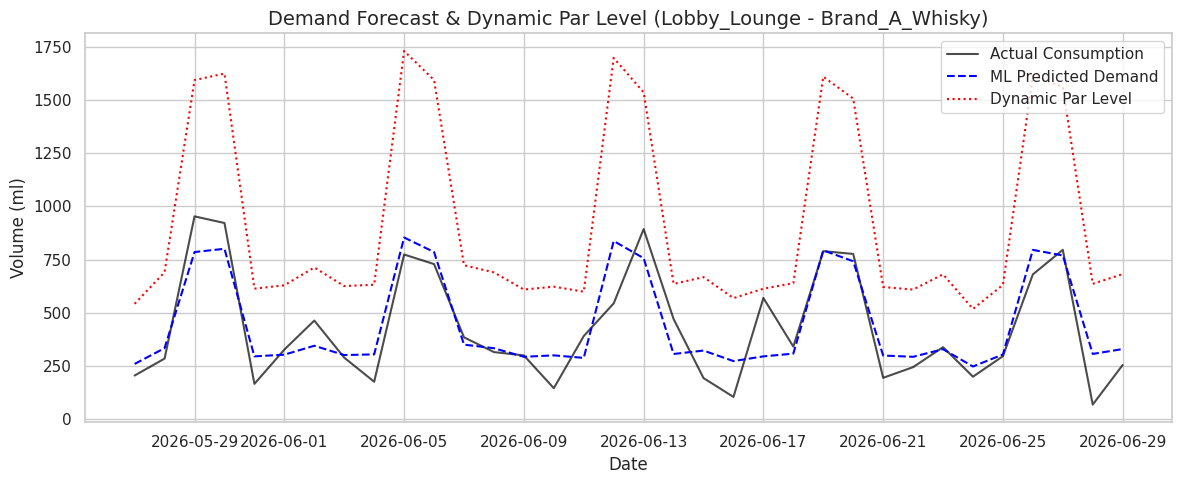

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_theme(style="whitegrid")

# ==========================================
# 1. PREPROCESSING & GRID RESAMPLING
# ==========================================
df = pd.read_csv('bar_inventory_data.csv')
df['Date Time Served'] = pd.to_datetime(df['Date Time Served'])
df['Date'] = df['Date Time Served'].dt.floor('D')

# Aggregate daily consumption
daily_agg = df.groupby(['Date', 'Bar Name', 'Brand Name'])['Consumed'].sum().reset_index()

# Create complete Cartesian Product (Zero-Demand Handling)
bars = daily_agg['Bar Name'].unique()
brands = daily_agg['Brand Name'].unique()
dates = pd.date_range(start=daily_agg['Date'].min(), end=daily_agg['Date'].max(), freq='D')

full_index = pd.MultiIndex.from_product([dates, bars, brands], names=['Date', 'Bar Name', 'Brand Name'])
daily_ts = daily_agg.set_index(['Date', 'Bar Name', 'Brand Name']).reindex(full_index, fill_value=0.0).reset_index()

print("✓ Step 1 Complete: Aggregated daily time-series with zero-fill created!")

# ==========================================
# 2. FEATURE ENGINEERING & TIME-SERIES SPLIT
# ==========================================
daily_ts = daily_ts.sort_values(['Bar Name', 'Brand Name', 'Date'])
group = daily_ts.groupby(['Bar Name', 'Brand Name'])['Consumed']

# Lags & Rolling features
daily_ts['lag_1'] = group.shift(1)
daily_ts['lag_7'] = group.shift(7)
daily_ts['lag_14'] = group.shift(14)
daily_ts['rolling_mean_7'] = group.shift(1).rolling(window=7).mean()
daily_ts['rolling_std_7'] = group.shift(1).rolling(window=7).std()
daily_ts['dayofweek'] = daily_ts['Date'].dt.dayofweek
daily_ts['is_weekend'] = daily_ts['dayofweek'].isin([4, 5]).astype(int)

# Drop missing values from lags
data = daily_ts.dropna().copy()

# Temporal Train/Validation Split (80% train, 20% test)
split_date = data['Date'].quantile(0.8)
train = data[data['Date'] < split_date]
test = data[data['Date'] >= split_date]

features = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'is_weekend']
target = 'Consumed'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# ==========================================
# 3. MODEL TRAINING & EVALUATION (WAPE)
# ==========================================
# Baseline Model (7-day rolling mean)
test['baseline_pred'] = test['rolling_mean_7']

# ML Model (LightGBM)
model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1)
model.fit(X_train, y_train)
test['ml_pred'] = model.predict(X_test)
test['ml_pred'] = np.maximum(0, test['ml_pred']) # Ensure no negative demand predictions

# WAPE Calculation
def calculate_wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

wape_baseline = calculate_wape(test['Consumed'], test['baseline_pred'])
wape_ml = calculate_wape(test['Consumed'], test['ml_pred'])

print(f"✓ Step 2 & 3 Complete!")
print(f"  - Baseline (7-Day Mean) WAPE: {wape_baseline:.2%}")
print(f"  - Machine Learning Model WAPE: {wape_ml:.2%}")

# ==========================================
# 4. PAR LEVEL & SAFETY STOCK CALCULATION
# ==========================================
# Parameters: Lead time = 2 days, Target Service Level = 95% (Z = 1.645)
L = 2
Z = 1.645

rmse = np.sqrt(mean_absolute_error(test['Consumed'], test['ml_pred']))
test['std_daily_demand'] = rmse
test['lead_time_demand'] = test['ml_pred'] * L
test['safety_stock'] = Z * (test['std_daily_demand'] * np.sqrt(L))
test['par_level'] = test['lead_time_demand'] + test['safety_stock']

# ==========================================
# 5. INVENTORY BACKTEST SIMULATION ENGINE
# ==========================================
def run_simulation(data_df):
    stockouts = 0
    total_days = len(data_df)
    stock = 5000.0  # Initial stock level in ml
    pending_orders = [] # [(delivery_day, quantity)]
    history = []

    for idx, row in data_df.reset_index().iterrows():
        current_day = idx

        # 1. Receive pending deliveries
        arrived = sum(qty for del_day, qty in pending_orders if del_day == current_day)
        stock += arrived
        pending_orders = [(d, q) for d, q in pending_orders if d > current_day]

        # 2. Fulfill actual demand
        actual_demand = row['Consumed']
        if stock >= actual_demand:
            stock -= actual_demand
        else:
            stockouts += 1
            stock = 0.0

        # 3. Check effective inventory and reorder
        effective_inv = stock + sum(q for _, q in pending_orders)
        if effective_inv < row['par_level']:
            order_qty = row['par_level'] - effective_inv
            pending_orders.append((current_day + L, order_qty))

        history.append(stock)

    return stockouts, np.mean(history)

# Run simulation on test set sample bar/brand
sample_subset = test[(test['Bar Name'] == bars[0]) & (test['Brand Name'] == brands[0])]
stockout_count, avg_holding = run_simulation(sample_subset)

print(f"✓ Step 4 & 5 Complete: Simulation Finished!")
print(f"  - Simulated Test Days: {len(sample_subset)}")
print(f"  - Total Stockout Days Occurred: {stockout_count}")
print(f"  - Average Daily Holding Stock: {avg_holding:.2f} ml")

# ==========================================
# VISUALIZATIONS
# ==========================================
plt.figure(figsize=(12, 5))
plt.plot(sample_subset['Date'], sample_subset['Consumed'], label='Actual Consumption', color='black', alpha=0.7)
plt.plot(sample_subset['Date'], sample_subset['ml_pred'], label='ML Predicted Demand', color='blue', linestyle='--')
plt.plot(sample_subset['Date'], sample_subset['par_level'], label='Dynamic Par Level', color='red', linestyle=':')
plt.title(f'Demand Forecast & Dynamic Par Level ({bars[0]} - {brands[0]})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume (ml)')
plt.legend()
plt.tight_layout()
plt.show()